In [1]:
!pip install torchvision -q

import torchvision

train_data = torchvision.datasets.GTSRB(root='./gtsrb_raw', split='train', download=True)
print('Скачано изображений:', len(train_data))

100%|██████████| 187M/187M [00:21<00:00, 8.82MB/s]


Скачано изображений: 26640


In [2]:
import pandas as pd, glob, os, random
from PIL import Image

random.seed(42)

base = './gtsrb_raw/gtsrb/GTSRB/Training'
csv_files = glob.glob(f'{base}/*/GT-*.csv')
print('Найдено CSV файлов (классов):', len(csv_files))

dfs = []
for csv_path in csv_files:
    class_dir = os.path.dirname(csv_path)
    df = pd.read_csv(csv_path, sep=';')
    df['Path'] = df['Filename'].apply(lambda f: os.path.join(class_dir, f))
    dfs.append(df)

full_df = pd.concat(dfs, ignore_index=True)
print('Всего изображений в датасете:', len(full_df))
print(full_df.columns.tolist())
full_df.head()

Найдено CSV файлов (классов): 43
Всего изображений в датасете: 26640
['Filename', 'Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,00000_00000.ppm,35,30,6,5,30,25,2,./gtsrb_raw/gtsrb/GTSRB/Training/00002/00000_0...
1,00000_00001.ppm,35,31,5,5,30,26,2,./gtsrb_raw/gtsrb/GTSRB/Training/00002/00000_0...
2,00000_00002.ppm,35,31,5,5,30,26,2,./gtsrb_raw/gtsrb/GTSRB/Training/00002/00000_0...
3,00000_00003.ppm,37,33,6,6,32,28,2,./gtsrb_raw/gtsrb/GTSRB/Training/00002/00000_0...
4,00000_00004.ppm,37,33,6,6,32,28,2,./gtsrb_raw/gtsrb/GTSRB/Training/00002/00000_0...


In [3]:
import os

random.seed(42)
df = full_df.sample(n=2500, random_state=42).reset_index(drop=True)

base_out = 'dataset'
for split in ['train', 'val']:
    os.makedirs(f'{base_out}/images/{split}', exist_ok=True)
    os.makedirs(f'{base_out}/labels/{split}', exist_ok=True)

n_val = int(len(df) * 0.15)
val_idx = set(random.sample(range(len(df)), n_val))

skipped = 0
for i, row in df.iterrows():
    split = 'val' if i in val_idx else 'train'
    try:
        img = Image.open(row['Path']).convert('RGB')
    except Exception as e:
        skipped += 1
        continue

    w, h = img.size
    class_id = int(row['ClassId'])

    x1, y1, x2, y2 = row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']
    x_c = (x1 + x2) / 2 / w
    y_c = (y1 + y2) / 2 / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h

    fname = f'img_{i}'
    img.save(f'{base_out}/images/{split}/{fname}.jpg')
    with open(f'{base_out}/labels/{split}/{fname}.txt', 'w') as f:
        f.write(f'{class_id} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n')

print('Готово. Пропущено (ошибки открытия):', skipped)
print('Train:', len(os.listdir(f'{base_out}/images/train')))
print('Val:', len(os.listdir(f'{base_out}/images/val')))

Готово. Пропущено (ошибки открытия): 0
Train: 2125
Val: 375


In [4]:
!pip install ultralytics -q

names_ru = {
0: 'Ограничение скорости 20', 1: 'Ограничение скорости 30', 2: 'Ограничение скорости 50',
3: 'Ограничение скорости 60', 4: 'Ограничение скорости 70', 5: 'Ограничение скорости 80',
6: 'Конец ограничения скорости 80', 7: 'Ограничение скорости 100', 8: 'Ограничение скорости 120',
9: 'Обгон запрещён', 10: 'Обгон грузовым запрещён', 11: 'Пересечение с второстепенной',
12: 'Главная дорога', 13: 'Уступите дорогу', 14: 'Стоп', 15: 'Движение запрещено',
16: 'Движение грузовых запрещено', 17: 'Въезд запрещён', 18: 'Прочие опасности',
19: 'Опасный поворот налево', 20: 'Опасный поворот направо', 21: 'Двойной поворот',
22: 'Неровная дорога', 23: 'Скользкая дорога', 24: 'Сужение дороги справа',
25: 'Дорожные работы', 26: 'Светофорное регулирование', 27: 'Пешеходный переход',
28: 'Дети', 29: 'Велосипедисты', 30: 'Гололёд', 31: 'Дикие животные',
32: 'Конец всех ограничений', 33: 'Поворот направо', 34: 'Поворот налево',
35: 'Движение прямо', 36: 'Прямо или направо', 37: 'Прямо или налево',
38: 'Объезд справа', 39: 'Объезд слева', 40: 'Круговое движение',
41: 'Конец запрета обгона', 42: 'Конец запрета обгона грузовым'
}

yaml_lines = ["path: /content/dataset", "train: images/train", "val: images/val", "names:"]
for k, v in names_ru.items():
    yaml_lines.append(f"  {k}: {v}")

with open('dataset/data.yaml', 'w', encoding='utf-8') as f:
    f.write('\n'.join(yaml_lines))

print(open('dataset/data.yaml', encoding='utf-8').read())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.1 MB/s eta 0:00:00
path: /content/dataset
train: images/train
val: images/val
names:
  0: Ограничение скорости 20
  1: Ограничение скорости 30
  2: Ограничение скорости 50
  3: Ограничение скорости 60
  4: Ограничение скорости 70
  5: Ограничение скорости 80
  6: Конец ограничения скорости 80
  7: Ограничение скорости 100
  8: Ограничение скорости 120
  9: Обгон запрещён
  10: Обгон грузовым запрещён
  11: Пересечение с второстепенной
  12: Главная дорога
  13: Уступите дорогу
  14: Стоп
  15: Движение запрещено
  16: Движение грузовых запрещено
  17: Въезд запрещён
  18: Прочие опасности
  19: Опасный поворот налево
  20: Опасный поворот направо
  21: Двойной поворот
  22: Неровная дорога
  23: Скользкая дорога
  24: Сужение дороги справа
  25: Дорожные работы
  26: Светофо

In [5]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset/data.yaml',
    epochs=30,
    imgsz=320,
    batch=16,
    patience=10,
    project='runs',
    name='road_signs',
    device=0
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

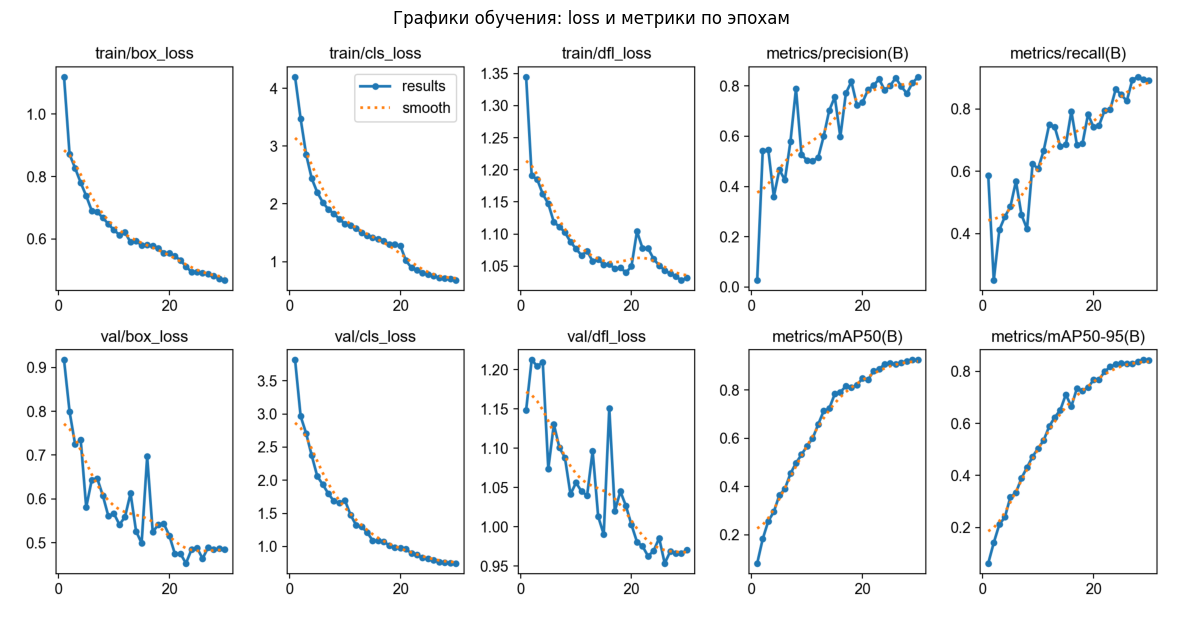

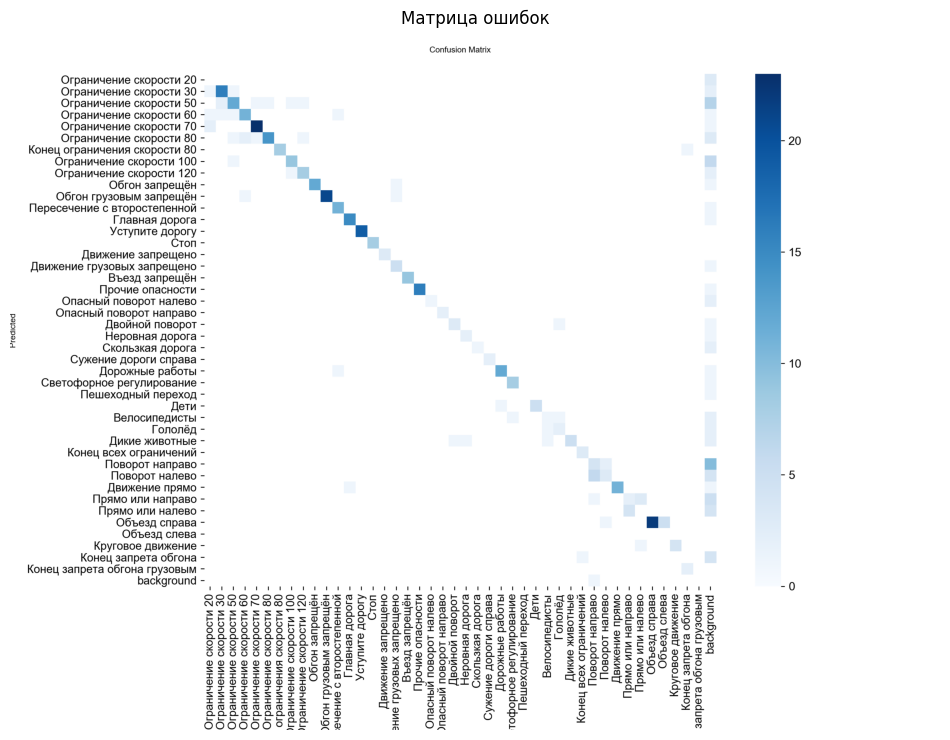

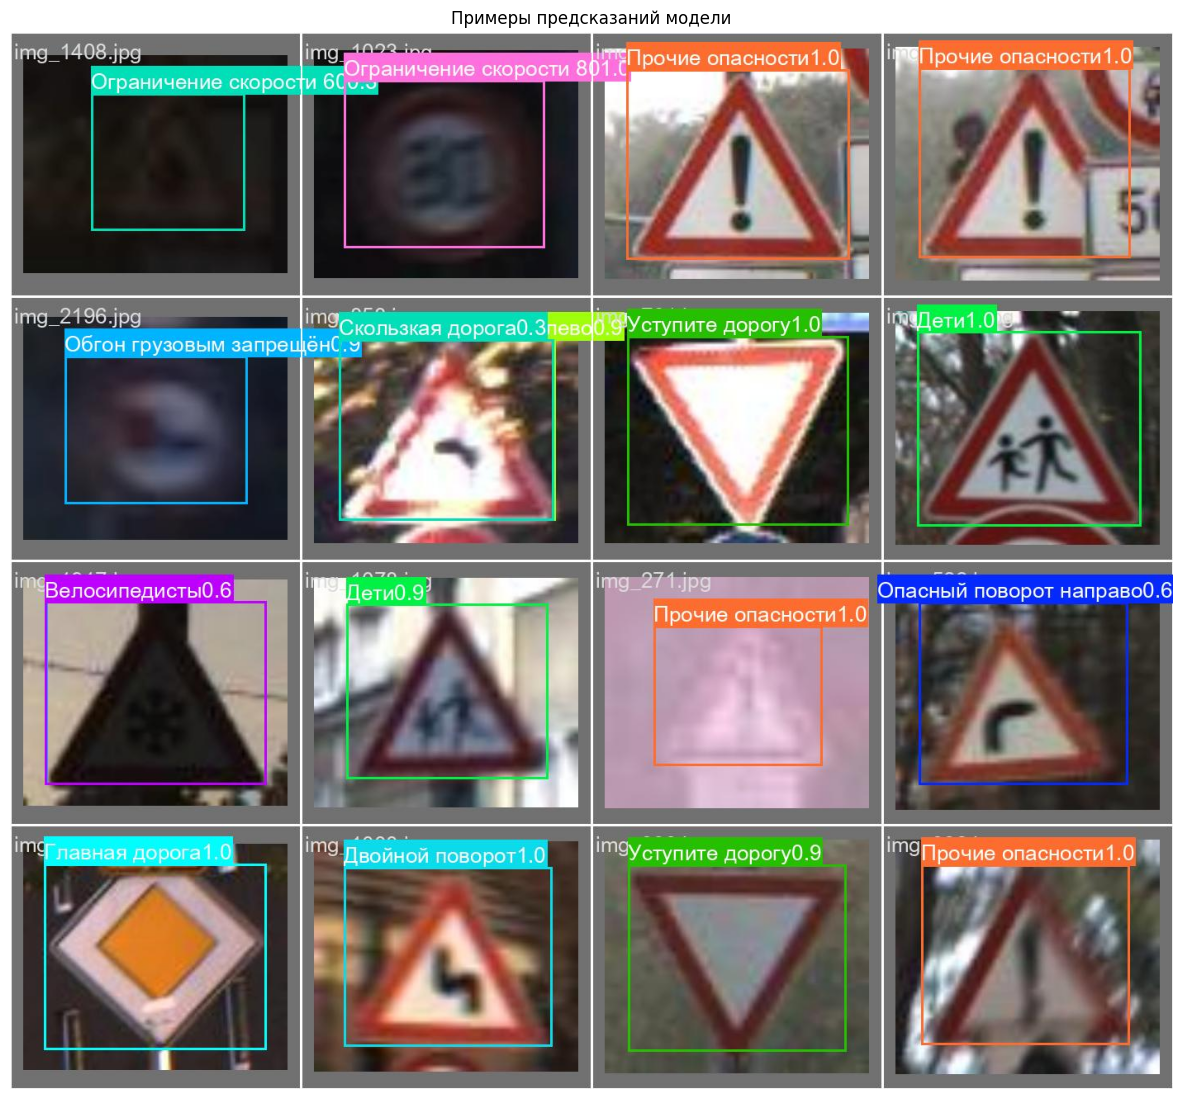

Все графики сохранены в: /content/runs/detect/runs/road_signs/


In [6]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

results_img = PILImage.open('/content/runs/detect/runs/road_signs/results.png')
plt.figure(figsize=(15,10))
plt.imshow(results_img)
plt.axis('off')
plt.title('Графики обучения: loss и метрики по эпохам')
plt.show()

cm_img = PILImage.open('/content/runs/detect/runs/road_signs/confusion_matrix.png')
plt.figure(figsize=(12,10))
plt.imshow(cm_img)
plt.axis('off')
plt.title('Матрица ошибок')
plt.show()

val_pred_img = PILImage.open('/content/runs/detect/runs/road_signs/val_batch0_pred.jpg')
plt.figure(figsize=(15,15))
plt.imshow(val_pred_img)
plt.axis('off')
plt.title('Примеры предсказаний модели')
plt.show()

print("Все графики сохранены в: /content/runs/detect/runs/road_signs/")

In [12]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import time

class YoloDataset(Dataset):
    def __init__(self, img_dir, label_dir, size=320):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.size = size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img_path = os.path.join(self.img_dir, fname)
        label_path = os.path.join(self.label_dir, fname.replace('.jpg', '.txt'))

        img = Image.open(img_path).convert('RGB').resize((self.size, self.size))
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        boxes, labels = [], []
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * self.size
                y1 = (yc - bh/2) * self.size
                x2 = (xc + bw/2) * self.size
                y2 = (yc + bh/2) * self.size
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls) + 1)

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = YoloDataset('dataset/images/train', 'dataset/labels/train')
val_ds = YoloDataset('dataset/images/val', 'dataset/labels/val')
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=2)

num_classes = 44
model_frcnn = fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda')
model_frcnn.to(device)

optimizer = torch.optim.SGD(model_frcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
scaler = torch.cuda.amp.GradScaler()

num_epochs = 10
loss_history = []

start = time.time()
for epoch in range(num_epochs):
    model_frcnn.train()
    epoch_loss = 0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss_dict = model_frcnn(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {(time.time()-start)/60:.1f} мин')

torch.save(model_frcnn.state_dict(), 'fasterrcnn_road_signs.pth')
print('Обучение завершено, модель сохранена')

/tmp/ipykernel_1162/3992424698.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1162/3992424698.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10, Loss: 0.3155, Time: 3.8 мин
Epoch 2/10, Loss: 0.1869, Time: 7.5 мин
Epoch 3/10, Loss: 0.1461, Time: 11.3 мин
Epoch 4/10, Loss: 0.1222, Time: 15.1 мин
Epoch 5/10, Loss: 0.1123, Time: 18.8 мин
Epoch 6/10, Loss: 0.1008, Time: 22.6 мин
Epoch 7/10, Loss: 0.0941, Time: 26.4 мин
Epoch 8/10, Loss: 0.0865, Time: 30.1 мин
Epoch 9/10, Loss: 0.0757, Time: 33.9 мин
Epoch 10/10, Loss: 0.0653, Time: 37.7 мин
Обучение завершено, модель сохранена


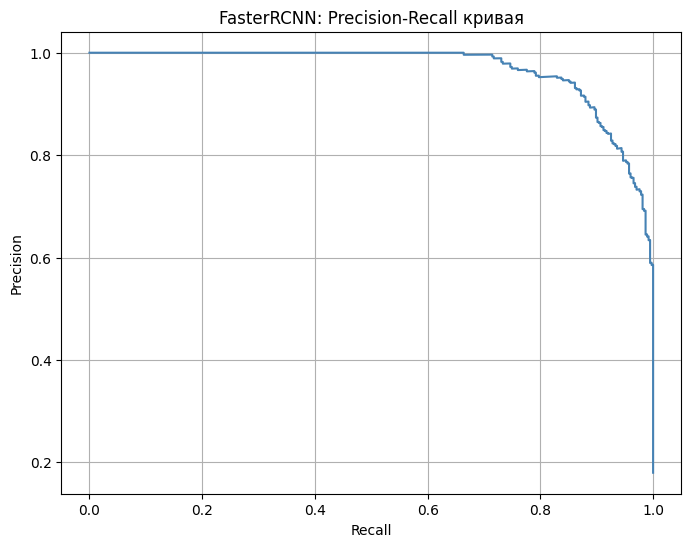

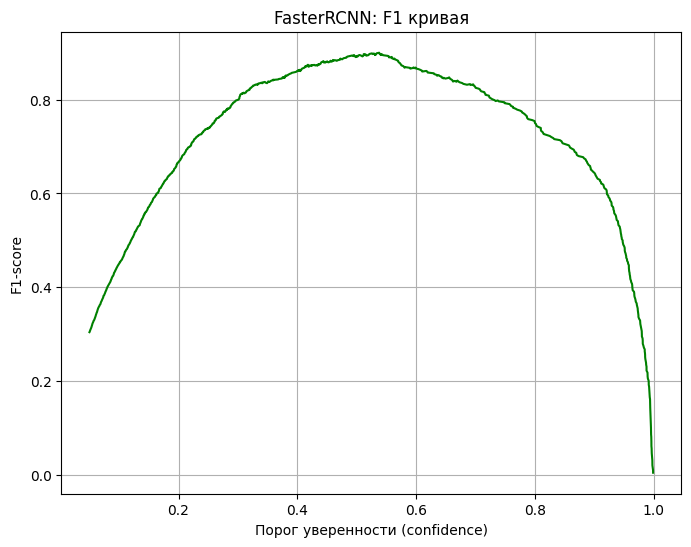

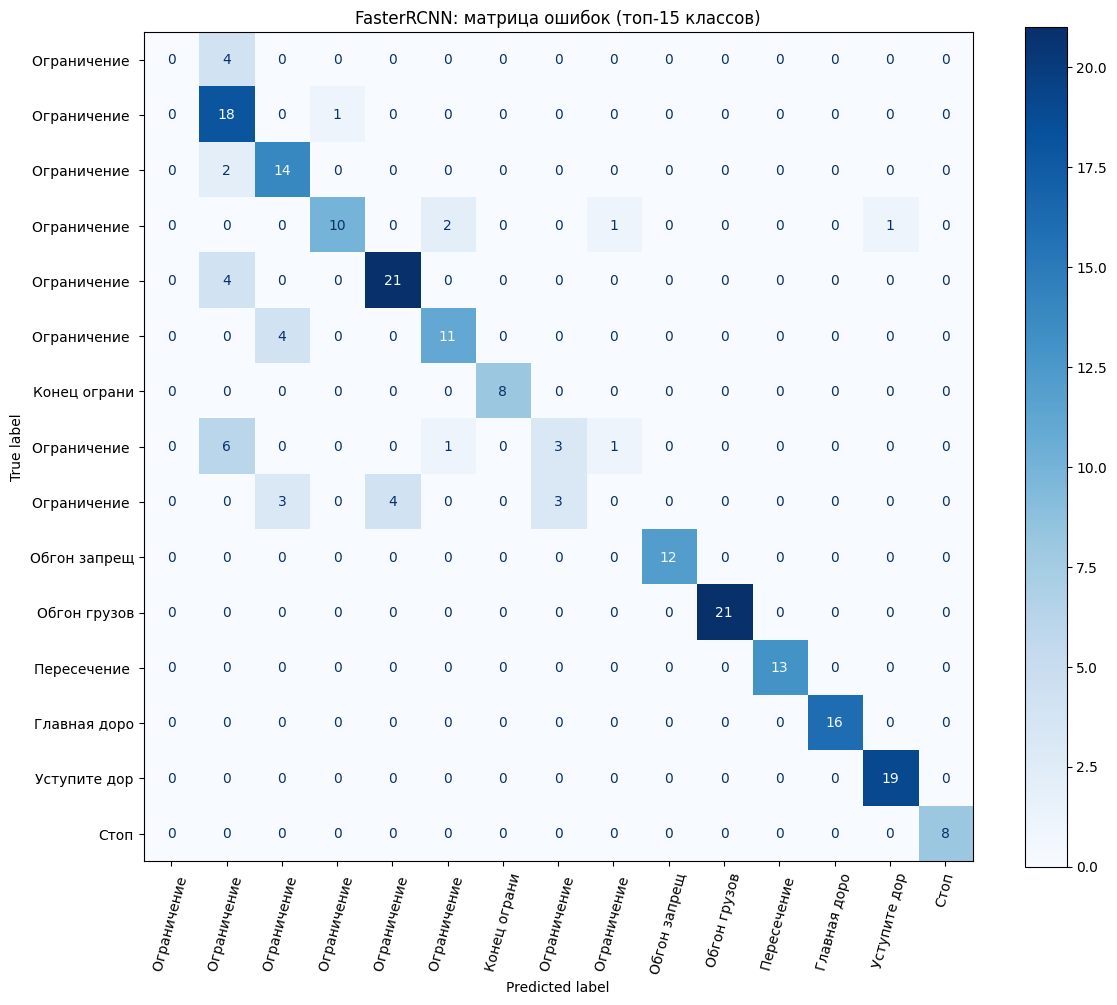

Лучший F1 для FasterRCNN: 0.900


In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay

def collect_matches(model, val_loader, device, iou_threshold=0.5):
    model.eval()
    all_scores, all_correct = [], []
    y_true_cls, y_pred_cls = [], []

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            preds = model(images)

            for pred, target in zip(preds, targets):
                pred_boxes = pred['boxes'].cpu()
                pred_scores = pred['scores'].cpu()
                pred_labels = pred['labels'].cpu()
                true_boxes = target['boxes']
                true_labels = target['labels']

                matched_true = set()
                if len(pred_boxes) > 0 and len(true_boxes) > 0:
                    ious = box_iou(pred_boxes, true_boxes)
                else:
                    ious = torch.zeros((len(pred_boxes), len(true_boxes)))

                for i in range(len(pred_boxes)):
                    all_scores.append(pred_scores[i].item())
                    if len(true_boxes) > 0:
                        best_iou, best_j = ious[i].max(0)
                        if best_iou >= iou_threshold and best_j.item() not in matched_true:
                            matched_true.add(best_j.item())
                            all_correct.append(1)
                            y_true_cls.append(true_labels[best_j].item())
                            y_pred_cls.append(pred_labels[i].item())
                        else:
                            all_correct.append(0)
                    else:
                        all_correct.append(0)

    return np.array(all_scores), np.array(all_correct), y_true_cls, y_pred_cls


def plot_pr_f1_confusion(model, val_loader, device, model_name, names_dict):
    scores, correct, y_true_cls, y_pred_cls = collect_matches(model, val_loader, device)

    precision, recall, thresholds = precision_recall_curve(correct, scores)
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, color='steelblue')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{model_name}: Precision-Recall кривая')
    plt.grid(True); plt.savefig(f'{model_name}_pr_curve.png'); plt.show()

    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    plt.figure(figsize=(8,6))
    plt.plot(thresholds, f1_scores[:-1], color='green')
    plt.xlabel('Порог уверенности (confidence)'); plt.ylabel('F1-score')
    plt.title(f'{model_name}: F1 кривая')
    plt.grid(True); plt.savefig(f'{model_name}_f1_curve.png'); plt.show()

    if len(y_true_cls) > 0:
        top_classes = sorted(set(y_true_cls))[:15]
        mask = [i for i, c in enumerate(y_true_cls) if c in top_classes]
        yt = [y_true_cls[i] for i in mask]
        yp = [y_pred_cls[i] for i in mask]
        labels_str = [names_dict.get(c-1, str(c))[:12] for c in top_classes]

        fig, ax = plt.subplots(figsize=(12,10))
        ConfusionMatrixDisplay.from_predictions(yt, yp, labels=top_classes, display_labels=labels_str,
                                                  ax=ax, xticks_rotation=75, cmap='Blues')
        plt.title(f'{model_name}: матрица ошибок (топ-15 классов)')
        plt.tight_layout(); plt.savefig(f'{model_name}_confusion_matrix.png'); plt.show()

    print(f'Лучший F1 для {model_name}: {f1_scores.max():.3f}')

plot_pr_f1_confusion(model_frcnn, val_loader, device, 'FasterRCNN', names_ru)

In [15]:
model3 = YOLO('yolov10n.pt')

results3 = model3.train(
    data='dataset/data.yaml',
    epochs=30,
    imgsz=320,
    batch=16,
    patience=10,
    project='runs',
    name='road_signs_yolov10n',
    device=0
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_signs_yolov10n, nbs=64, nms=None, opset=None, optimi

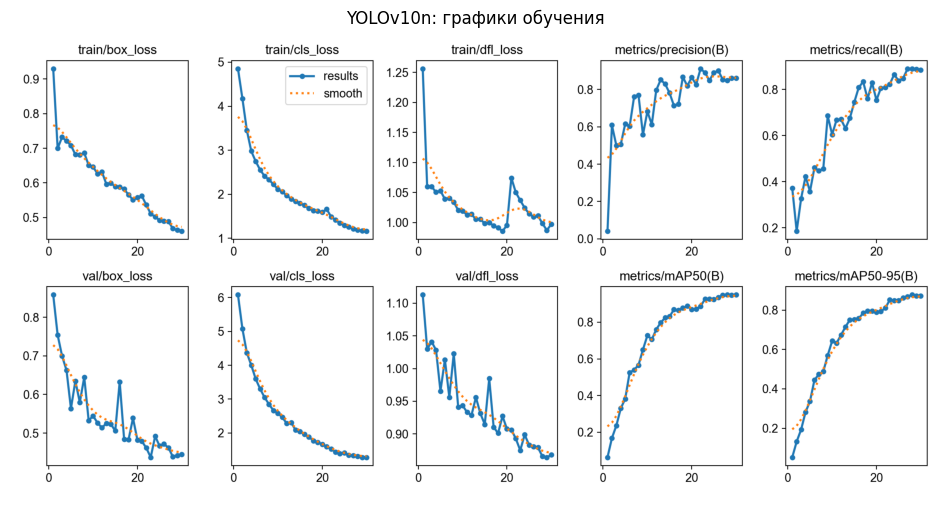

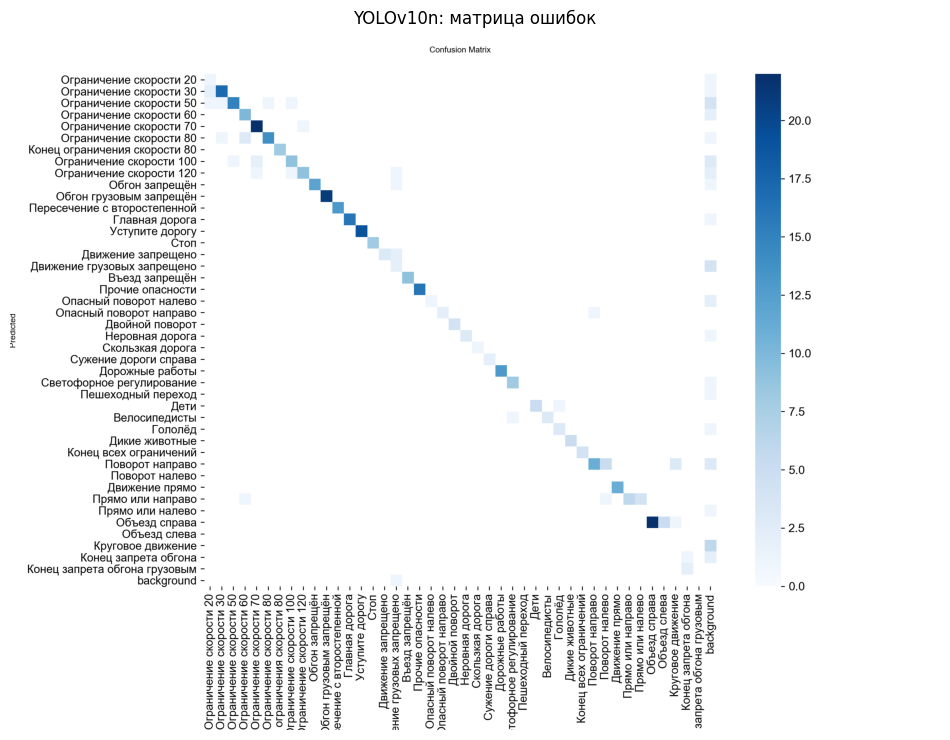

In [22]:
from PIL import Image as PILImage
import matplotlib.pyplot as plt

for img_name, title in [('results.png', 'YOLOv10n: графики обучения'),
                          ('confusion_matrix.png', 'YOLOv10n: матрица ошибок')]:
    img = PILImage.open(f'/content/runs/detect/runs/road_signs_yolov10n/{img_name}')
    plt.figure(figsize=(12,10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

In [23]:
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection._utils import retrieve_out_channels

class SSDDataset(Dataset):
    def __init__(self, img_dir, label_dir, size=300):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.size = size

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB').resize((self.size, self.size))
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        boxes, labels = [], []
        with open(os.path.join(self.label_dir, fname.replace('.jpg', '.txt'))) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())
                x1 = max((xc - bw/2) * self.size, 0)
                y1 = max((yc - bh/2) * self.size, 0)
                x2 = min((xc + bw/2) * self.size, self.size)
                y2 = min((yc + bh/2) * self.size, self.size)
                boxes.append([x1, y1, x2, y2])
                labels.append(int(cls) + 1)

        return img_tensor, {'boxes': torch.tensor(boxes, dtype=torch.float32),
                             'labels': torch.tensor(labels, dtype=torch.int64)}

train_ds_ssd = SSDDataset('dataset/images/train', 'dataset/labels/train')
val_ds_ssd = SSDDataset('dataset/images/val', 'dataset/labels/val')
train_loader_ssd = DataLoader(train_ds_ssd, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader_ssd = DataLoader(val_ds_ssd, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=2)

num_classes = 44
model_ssd = ssd300_vgg16(weights='DEFAULT')
in_channels = retrieve_out_channels(model_ssd.backbone, (300, 300))
num_anchors = model_ssd.anchor_generator.num_anchors_per_location()
model_ssd.head.classification_head = SSDClassificationHead(in_channels, num_anchors, num_classes)
model_ssd.to(device)

optimizer_ssd = torch.optim.SGD(model_ssd.parameters(), lr=0.002, momentum=0.9, weight_decay=0.0005)
scaler_ssd = torch.amp.GradScaler('cuda')

num_epochs = 15
loss_history_ssd = []
start = time.time()

for epoch in range(num_epochs):
    model_ssd.train()
    epoch_loss = 0
    for images, targets in train_loader_ssd:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer_ssd.zero_grad()
        with torch.amp.autocast('cuda'):
            loss_dict = model_ssd(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler_ssd.scale(losses).backward()
        scaler_ssd.step(optimizer_ssd)
        scaler_ssd.update()
        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_loader_ssd)
    loss_history_ssd.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {(time.time()-start)/60:.1f} мин')

torch.save(model_ssd.state_dict(), 'ssd_road_signs.pth')
print('SSD обучение завершено')

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:00<00:00, 171MB/s]


Epoch 1/15, Loss: 5.9963, Time: 0.7 мин
Epoch 2/15, Loss: 4.0588, Time: 1.4 мин
Epoch 3/15, Loss: 3.9251, Time: 2.0 мин
Epoch 4/15, Loss: 3.6673, Time: 2.7 мин
Epoch 5/15, Loss: 3.2336, Time: 3.4 мин
Epoch 6/15, Loss: 2.8487, Time: 4.0 мин
Epoch 7/15, Loss: 2.4524, Time: 4.7 мин
Epoch 8/15, Loss: 2.0783, Time: 5.4 мин
Epoch 9/15, Loss: 1.6345, Time: 6.0 мин
Epoch 10/15, Loss: 1.3073, Time: 6.7 мин
Epoch 11/15, Loss: 0.9706, Time: 7.4 мин
Epoch 12/15, Loss: 0.7228, Time: 8.0 мин
Epoch 13/15, Loss: 0.6171, Time: 8.7 мин
Epoch 14/15, Loss: 0.4651, Time: 9.4 мин
Epoch 15/15, Loss: 0.3210, Time: 10.1 мин
SSD обучение завершено


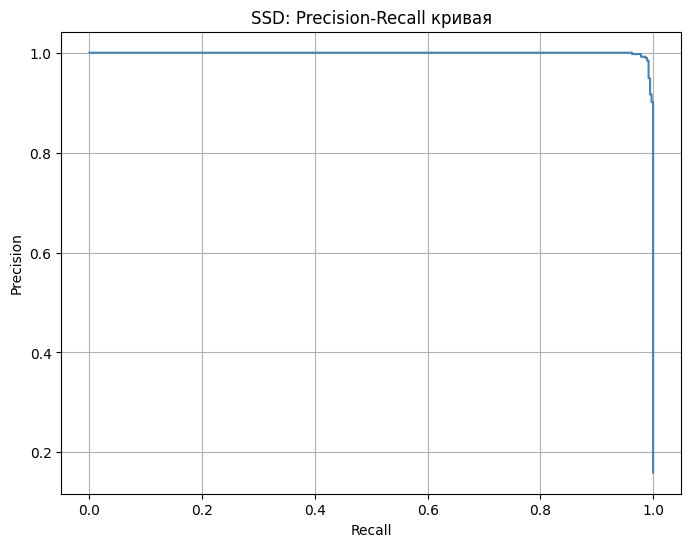

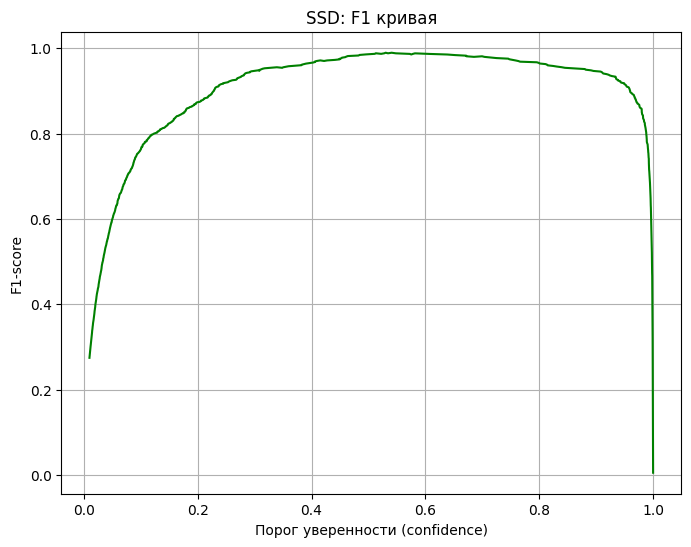

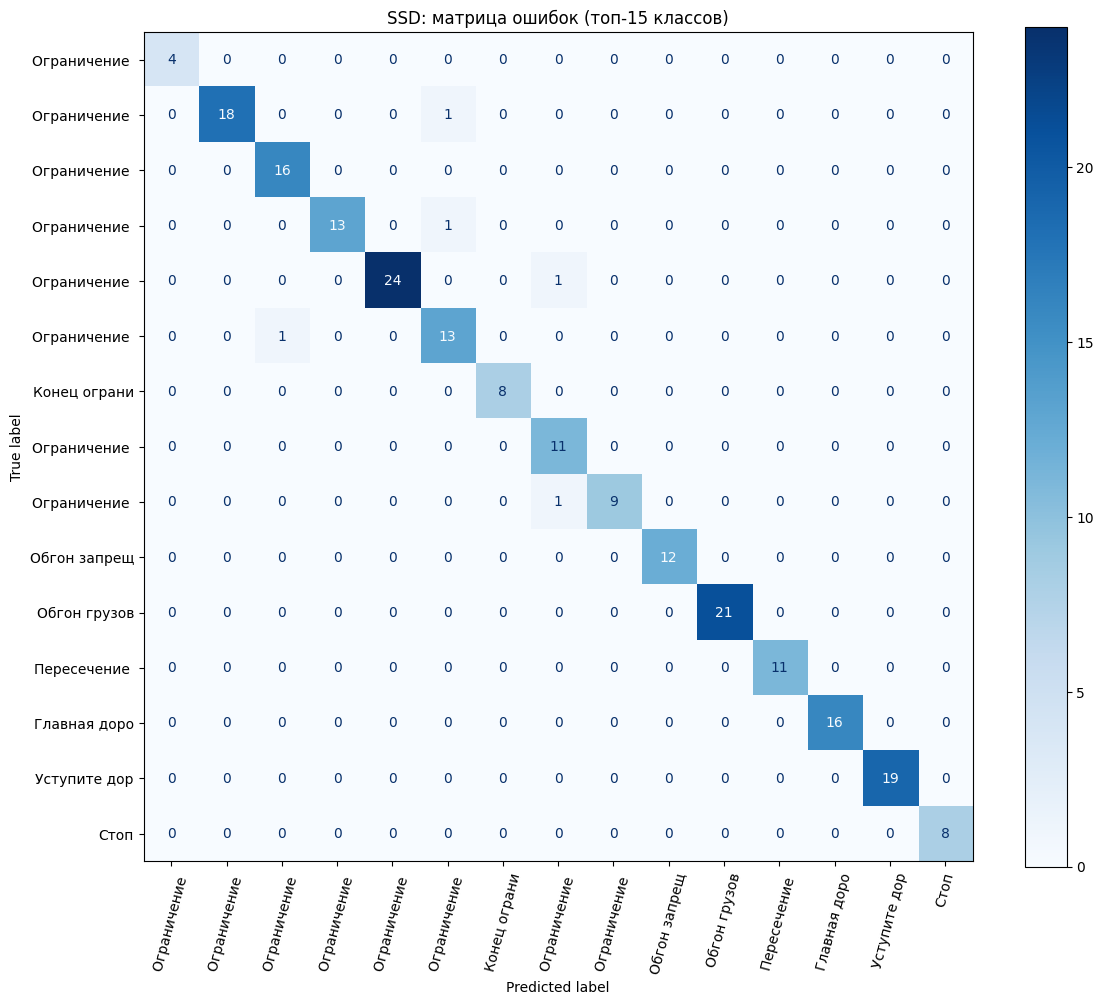

Лучший F1 для SSD: 0.989


In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay

def collect_matches(model, val_loader, device, iou_threshold=0.5):
    model.eval()
    all_scores, all_correct = [], []
    y_true_cls, y_pred_cls = [], []

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            preds = model(images)

            for pred, target in zip(preds, targets):
                pred_boxes = pred['boxes'].cpu()
                pred_scores = pred['scores'].cpu()
                pred_labels = pred['labels'].cpu()
                true_boxes = target['boxes']
                true_labels = target['labels']

                matched_true = set()
                if len(pred_boxes) > 0 and len(true_boxes) > 0:
                    ious = box_iou(pred_boxes, true_boxes)
                else:
                    ious = torch.zeros((len(pred_boxes), len(true_boxes)))

                for i in range(len(pred_boxes)):
                    all_scores.append(pred_scores[i].item())
                    if len(true_boxes) > 0:
                        best_iou, best_j = ious[i].max(0)
                        if best_iou >= iou_threshold and best_j.item() not in matched_true:
                            matched_true.add(best_j.item())
                            all_correct.append(1)
                            y_true_cls.append(true_labels[best_j].item())
                            y_pred_cls.append(pred_labels[i].item())
                        else:
                            all_correct.append(0)
                    else:
                        all_correct.append(0)

    return np.array(all_scores), np.array(all_correct), y_true_cls, y_pred_cls


def plot_pr_f1_confusion(model, val_loader, device, model_name, names_dict):
    scores, correct, y_true_cls, y_pred_cls = collect_matches(model, val_loader, device)

    precision, recall, thresholds = precision_recall_curve(correct, scores)
    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, color='steelblue')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{model_name}: Precision-Recall кривая')
    plt.grid(True); plt.savefig(f'{model_name}_pr_curve.png'); plt.show()

    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    plt.figure(figsize=(8,6))
    plt.plot(thresholds, f1_scores[:-1], color='green')
    plt.xlabel('Порог уверенности (confidence)'); plt.ylabel('F1-score')
    plt.title(f'{model_name}: F1 кривая')
    plt.grid(True); plt.savefig(f'{model_name}_f1_curve.png'); plt.show()

    if len(y_true_cls) > 0:
        top_classes = sorted(set(y_true_cls))[:15]
        mask = [i for i, c in enumerate(y_true_cls) if c in top_classes]
        yt = [y_true_cls[i] for i in mask]
        yp = [y_pred_cls[i] for i in mask]
        labels_str = [names_dict.get(c-1, str(c))[:12] for c in top_classes]

        fig, ax = plt.subplots(figsize=(12,10))
        ConfusionMatrixDisplay.from_predictions(yt, yp, labels=top_classes, display_labels=labels_str,
                                                  ax=ax, xticks_rotation=75, cmap='Blues')
        plt.title(f'{model_name}: матрица ошибок (топ-15 классов)')
        plt.tight_layout(); plt.savefig(f'{model_name}_confusion_matrix.png'); plt.show()

    print(f'Лучший F1 для {model_name}: {f1_scores.max():.3f}')

plot_pr_f1_confusion(model_ssd, val_loader_ssd, device, 'SSD', names_ru)

In [26]:
from ultralytics import RTDETR

model5 = RTDETR('rtdetr-l.pt')

results5 = model5.train(
    data='dataset/data.yaml',
    epochs=25,
    imgsz=320,
    batch=8,
    patience=10,
    project='runs',
    name='road_signs_rtdetr',
    device=0
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_signs_rtdetr, nbs=64, nms=None, opset=None, optimize=

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/25      6.68G     0.4215      3.394     0.5631         11        320: 100% ━━━━━━━━━━━━ 266/266 2.6it/s 1:44
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.5it/s 9.4s
                   all        375        375      0.208      0.372     0.0267     0.0192

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/25      6.68G     0.2985       2.25     0.4558         14        320: 0% ──────────── 0/266  0.4s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/25      6.68G     0.2666       1.59      0.369         17        320: 100% ━━━━━━━━━━━━ 266/266 3.1it/s 1:27
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.5it/s 3.2s
                   all        375        375      0.473      0.406      0.181      0.126

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/25      6.68G     0.2269      1.581     0.3231         18        320: 0% ──────────── 0/266  0.3s

...

      23/25      6.68G     0.1124     0.2359     0.2318          5        320: 100% ━━━━━━━━━━━━ 266/266 3.2it/s 1:23
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.4it/s 3.2s
                   all        375        375      0.866      0.931      0.948       0.79

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      24/25      6.68G     0.1043     0.2773     0.2142          8        320: 0% ──────────── 0/266  0.4s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      24/25      6.68G     0.1127     0.2303     0.2337          5        320: 100% ━━━━━━━━━━━━ 266/266 3.2it/s 1:22
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 6.9it/s 3.5s
                   all        375        375      0.862      0.932      0.949      0.794

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      25/25      6.68G     0.1022     0.1911     0.2441          8        320: 0% ──────────── 0/266  0.3s

/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      25/25      6.68G      0.109     0.2257     0.2275          5        320: 100% ━━━━━━━━━━━━ 266/266 3.2it/s 1:23
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.4it/s 3.2s
                   all        375        375      0.873      0.934      0.953      0.799

25 epochs completed in 0.698 hours.
Optimizer stripped from /content/runs/detect/runs/road_signs_rtdetr/weights/last.pt, 66.3MB
Optimizer stripped from /content/runs/detect/runs/road_signs_rtdetr/weights/best.pt, 66.3MB

Validating /content/runs/detect/runs/road_signs_rtdetr/weights/best.pt...
Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary (fused): 315 layers, 32,072,105 parameters, 0 gradients, 105.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.8it/s 6.4s
                   all        375        375      0.873      0.934     

Найдено: /content/runs/detect/runs/road_signs_rtdetr


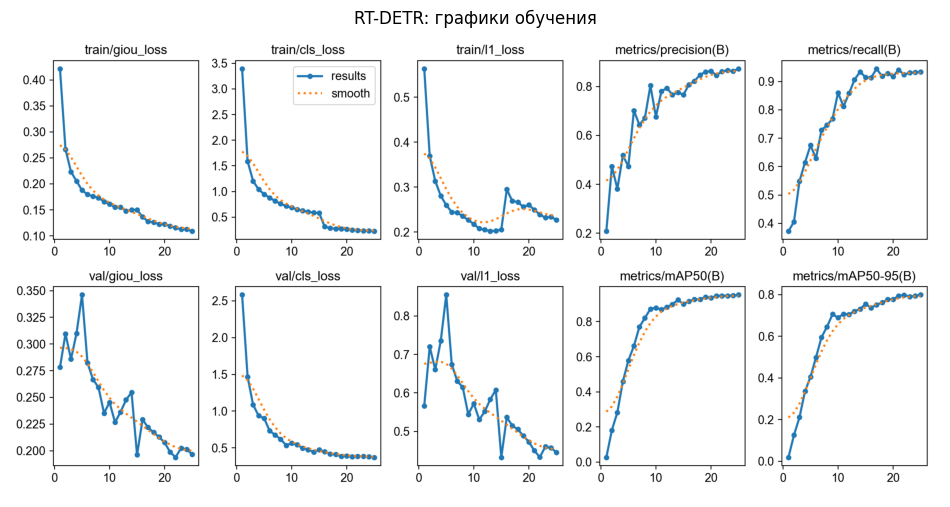

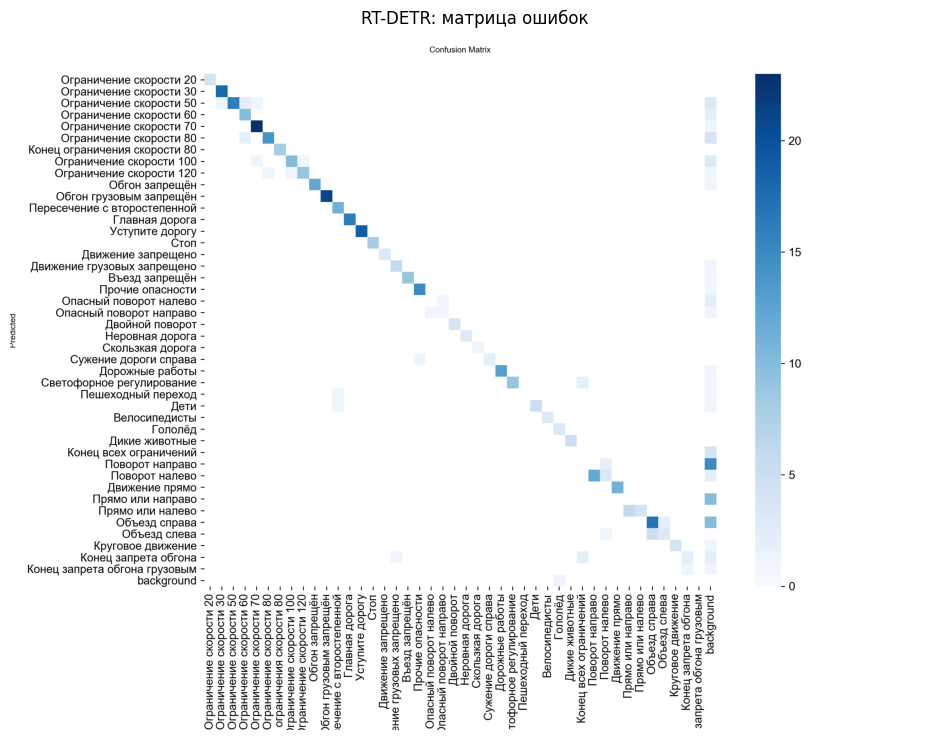

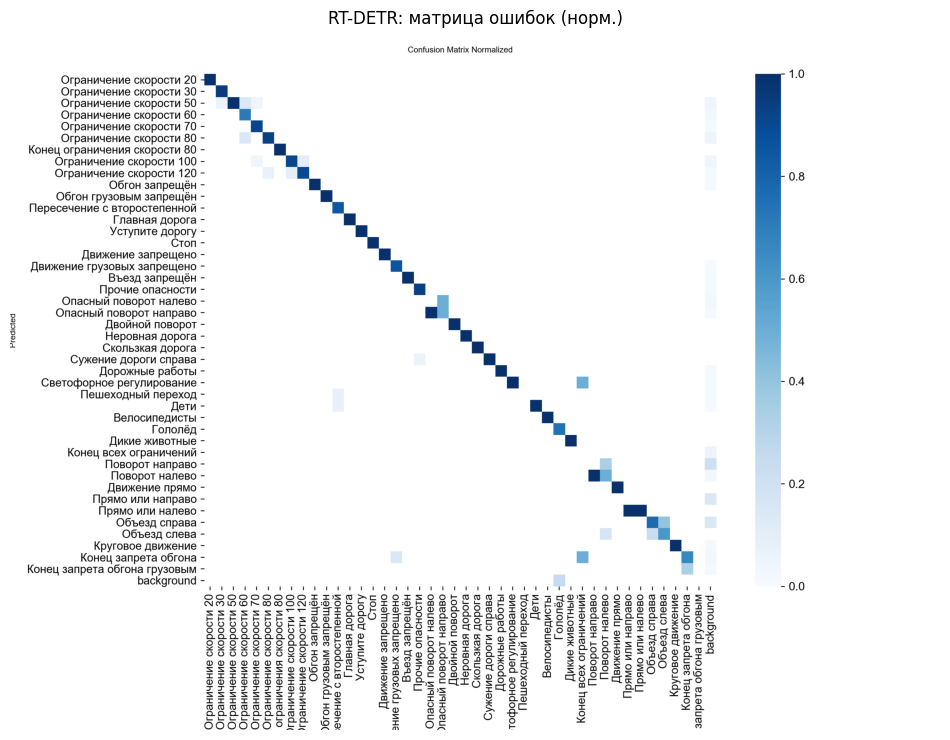

Не найден: PR_curve.png
Не найден: F1_curve.png


In [29]:
import os
import glob
from PIL import Image as PILImage
import matplotlib.pyplot as plt

def find_and_show(run_name, model_title):
    matches = glob.glob(f'/content/runs/**/{run_name}', recursive=True)
    if not matches:
        print(f'Папка {run_name} не найдена')
        return

    run_dir = matches[0]
    print(f'Найдено: {run_dir}')

    for img_name, title in [('results.png', f'{model_title}: графики обучения'),
                              ('confusion_matrix.png', f'{model_title}: матрица ошибок'),
                              ('confusion_matrix_normalized.png', f'{model_title}: матрица ошибок (норм.)'),
                              ('PR_curve.png', f'{model_title}: Precision-Recall кривая'),
                              ('F1_curve.png', f'{model_title}: F1 кривая')]:
        img_path = os.path.join(run_dir, img_name)
        if os.path.exists(img_path):
            img = PILImage.open(img_path)
            plt.figure(figsize=(12,10))
            plt.imshow(img)
            plt.axis('off')
            plt.title(title)
            plt.show()
        else:
            print(f'Не найден: {img_name}')

find_and_show('road_signs_rtdetr', 'RT-DETR')